Chapter 3 gave us the graphics needed to see what a series is doing. This chapter turns one of those observations into a formal property: **stationarity**.

A model estimates **one** set of parameters from the **whole** sample, and that is only meaningful if the same mechanism generated all of it. So the practical workflow is always the same:

1. Look at the series,
2. Test whether it is **stationary**,
3. If it is not, **transform** it until it is,
4. Model the transformed series,
5. Invert the transformation to put forecasts back on the original scale.

# Learning objectives

By the end of this lecture you should be able to:

1. State the definitions of **strict** and **weak (covariance) stationarity**, and explain why weak stationarity is the one used in practice.
2. Define **autocovariance** and the **autocorrelation function (ACF)**, and say what stationarity implies about them.
3. Recognise the standard patterns on sight: white noise, AR(1), random walk, trend,
   heteroscedasticity, seasonality, and the traps (a random-phase sinusoid, a cycle of non-fixed period).
4. Detect nonstationarity with **run-sequence plots**, **chunk and rolling statistics**, and the **ADF** and **KPSS** hypothesis tests, and interpret the two tests together.
5. Apply the four workhorse transformations, i.e., **detrending/deseasonalising**, **log/Box-Cox**, **differencing**, **seasonal differencing**, and invert them.
6. Recognise **over-differencing** and the situations in which the unit-root tests mislead you.


# Setup

Modules and functions used in this lecture.

| Module | Used for |
|---|---|
| `numpy` | `random.default_rng`, `cumsum`, `diff`, `log`, `linspace`, `polyfit` |
| `pandas` | `read_csv`, `DataFrame`, `Series`, `asfreq`, `diff`, `rolling`, `describe` |
| `matplotlib.pyplot` | `subplots`, `plot`, `axhline`, `fill_between` |
| `seaborn` | `histplot`, `color_palette` |
| `scipy.integrate` | `quad` (ensemble mean of a random-phase sinusoid) |
| `scipy.stats` | `pearsonr`, `boxcox` |
| `statsmodels.tsa.arima_process` | `ArmaProcess` -- simulate AR/MA processes |
| `statsmodels.tsa.stattools` | `acf`, `adfuller` (ADF test), `kpss` (KPSS test) |
| `statsmodels.tsa.seasonal` | `seasonal_decompose` |
| `statsmodels.graphics.tsaplots` | `plot_acf` |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import quad
from scipy.stats import pearsonr, boxcox

import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Two kinds of expected noise we do not want in the output:
#  - KPSS warns whenever its p-value falls outside the lookup table (that IS the answer, not an error);
#  - statsmodels 0.15 announces a future change to the return type of adfuller/kpss.
from statsmodels.tools.sm_exceptions import InterpolationWarning

# Reproducibility: one generator, seeded once.
rng = np.random.default_rng(8990)

print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {mpl.__version__}")
print(f"seaborn     {sns.__version__}")
print(f"statsmodels {sm.__version__}")

pandas      2.3.3
numpy       2.3.2
matplotlib  3.10.6
seaborn     0.13.2
statsmodels 0.15.0


In [2]:
# Locate the course data directory (works from the course root, from a Notes/ subfolder, or beside the data)
CANDIDATES = [Path("../Data"), Path("Data"), Path("../../Data"), Path(".")]
DATA_DIR = next((p for p in CANDIDATES if (p / "aus_production.csv").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the course Data/ folder. Set DATA_DIR manually, e.g.\n"
        '    DATA_DIR = Path(r"E:/.../ME 8990 - Time Series Forecasting/Data")'
    )

print("Data directory:", DATA_DIR.resolve())
print(len(list(DATA_DIR.glob("*.csv"))), "csv files available")

Data directory: E:\PythonProject\Time Series Forecasting (ME8990)\data
7 csv files available


One helper we will reuse throughout: a **run-sequence plot** is simply the value plotted against time.
It is the first diagnostic for stationarity and we will draw dozens of them.

In [3]:
def run_sequence_plot(y, x=None, title="", xlabel="time", ylabel="value",
                      ax=None, figsize=(9, 3), color="blue", **kwargs):
    "Plot a series against time and return the axes."
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    if x is None:
        x = getattr(y, "index", np.arange(len(y)))
    ax.plot(x, y, color=color, lw=1, **kwargs)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.3)
    return ax

# What is stationarity?

The **intuition**: a time series is stationary when there are no changes in the underlying system that generates it. 

- In the following, we define:
    - Strict stationarity.
    - Weak stationarity.
    - Things to check in practice.

**Note**: stationarity is a property of the **stochastic process** that generated the data, not of the particular sample sitting in your `DataFrame`. 

## Strict stationarity

A stochastic process $\{x_t\}$ is **strictly stationary** if the joint distribution of any collection of observations
is unchanged by a shift in time: for every $k$, every set of times $t_1 < \dots < t_k$, and every lag
$\tau$,

$$
F(x_{t_1}, \dots, x_{t_k}) \stackrel{\text{D}}{=} F(x_{t_1+\tau}, \dots, x_{t_k+\tau}).
$$

where $\stackrel{\text{D}}{=}$ indicates that the distributions are equal. 
In plain words, the joint distribution of any set of observations in the series remains the same regardless of the time at which the observations are taken.

- Strict stationarity is very difficult to verify, especially from a limited amount of data.
- For this reason, one checks the *Weak stationarity*.

## Weak (covariance) stationarity

In practice we require only the first two moments to be time-invariant. A process is **weakly stationary**
(equivalently *second-order* or *covariance* stationary) if

| # | Condition | Meaning |
|---|---|---|
| 1 | $\mathbb{E}[x_t] = \mu$ for all $t$ | constant **level** -- no trend, no drift |
| 2 | $\mathrm{Var}(x_t) = \sigma^2 < \infty$ for all $t$ | constant, finite **spread** -- no heteroscedasticity |
| 3 | $\mathrm{Cov}(x_t, x_{t+k}) = \gamma(k)$ for all $t$ | dependence between two points depends **only on the lag $k$**, not on where they sit |

Relationships worth remembering:

* strict stationarity **+ finite second moments** $\Rightarrow$ weak stationarity;
* weak stationarity $\not\Rightarrow$ strict stationarity -- **except** for Gaussian processes, where the
  first two moments determine the entire distribution, so the two notions coincide;
* "stationary", unqualified, means **weakly stationary** in this course and in the forecasting literature.

## A practical checklist

1. Constant mean (no trend).
2. Constant variance (no heteroskedasticity).
3. Constant autocorrelation structure.
4. No periodic component (be careful here)

| Question | If the answer is "no" | Fix (Chapter 5, Section 6) |
|---|---|---|
| Is the level roughly constant? | trend or drift $\rightarrow$ condition 1 fails | detrend, or difference |
| Is the spread roughly constant? | heteroscedasticity $\rightarrow$ condition 2 fails | log / Box-Cox |
| Are there repeating patterns at a fixed calendar period? | seasonality $\rightarrow$ condition 1 fails | seasonal differencing, or deseasonalise |
| Does the ACF die out quickly? | slow decay $\rightarrow$ condition 3 in doubt (unit root) | difference |


# Autocorrelation

Autocorrelation measures how much the current time series measurement is correlated with a past measurement.

Condition 3 above is about **autocovariance**: the covariance of a series with a lagged copy of itself.
For a stationary process, at lag $k$,

$$
\gamma(k) \;=\; \mathrm{Cov}(x_t, x_{t+k}) \;=\; \mathbb{E}\big[(x_t-\mu)(x_{t+k}-\mu)\big],
$$

and the **autocorrelation function (ACF)** is its normalised version,

$$
\rho(k) \;=\; \frac{\gamma(k)}{\gamma(0)} \in [-1, 1], \qquad \rho(0)=1 .
$$

From data we estimate it with

$$
\hat{\rho}(k) \;=\; \frac{\sum_{t=1}^{T-k} (x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{T} (x_t - \bar{x})^2},
$$

which uses a **single** sample mean $\bar{x}$ for the whole record, which is an estimator that only makes sense if
the mean really is constant. The ACF is therefore both a *tool for* diagnosing stationarity and something
that *presupposes* it; read a slowly-decaying ACF as a warning, not as an estimate.

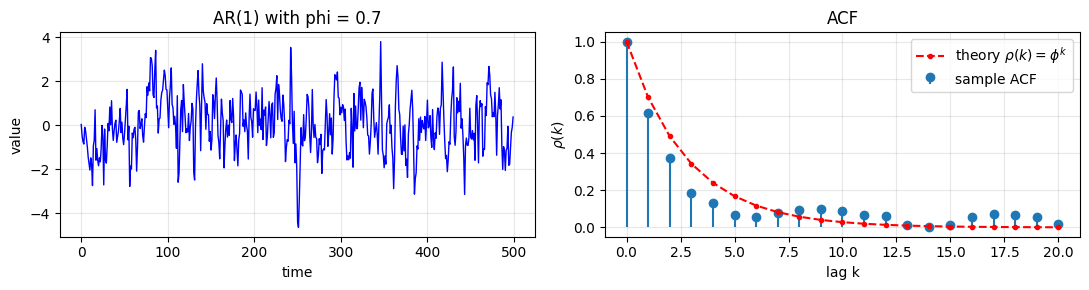

In [4]:
# AR(1): x_t = phi * x_{t-1} + eps_t.  
# Theory: rho(k) = phi**k, stationary iff |phi| < 1.
phi = 0.7
ar1 = ArmaProcess(ar=np.r_[1, -phi], ma=np.r_[1]).generate_sample(nsample=500, distrvs=rng.standard_normal)

lags = 20
sample_acf = acf(ar1, nlags=lags)
theory_acf = phi ** np.arange(lags + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
run_sequence_plot(ar1, title=f"AR(1) with phi = {phi}", ax=axes[0])
axes[1].stem(range(lags + 1), sample_acf, basefmt=" ", label="sample ACF")
axes[1].plot(range(lags + 1), theory_acf, "r--o", ms=3, label=r"theory $\rho(k)=\phi^k$")
axes[1].set(title="ACF", xlabel="lag k", ylabel=r"$\rho(k)$"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Stationary and nonstationary time series



## White noise -- the reference stationary process

$x_t \sim \mathcal{N}(\mu, \sigma^2)$, independent across $t$. Constant mean, constant variance,
$\gamma(k) = 0$ for $k \neq 0$. It is stationary by construction, and it is what we want the **residuals**
of a good model to look like.

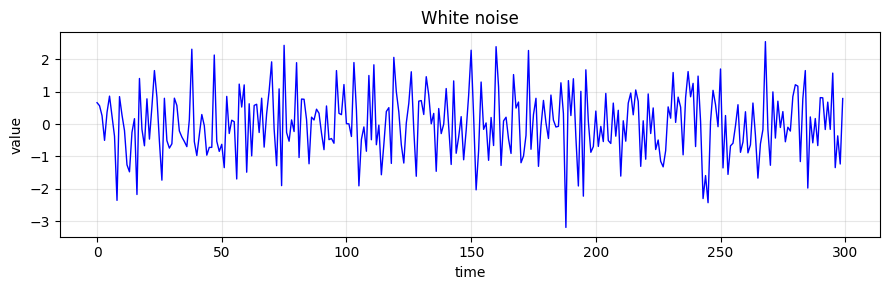

first half : mean =  0.025, var = 0.924
second half: mean = -0.010, var = 1.072


In [5]:
white_noise = rng.normal(loc=0.0, scale=1.0, size=300)
run_sequence_plot(white_noise, title="White noise")
plt.tight_layout(); plt.show()

print(f"first half : mean = {white_noise[:150].mean(): .3f}, var = {white_noise[:150].var():.3f}")
print(f"second half: mean = {white_noise[150:].mean(): .3f}, var = {white_noise[150:].var():.3f}")

## AR(1) -- stationary with memory

$x_t = \phi x_{t-1} + \varepsilon_t$ is stationary **iff $|\phi| < 1$**, with
$\mathbb{E}[x_t]=0$ and $\mathrm{Var}(x_t)=\sigma^2/(1-\phi^2)$. Observations are correlated, but the level
and the spread do not change: *stationary does not mean independent*.

As $\phi \to 1$ the process wanders further and takes longer to return, and at $\phi = 1$ it stops being
stationary altogether -- that is exactly the random walk of the next section.

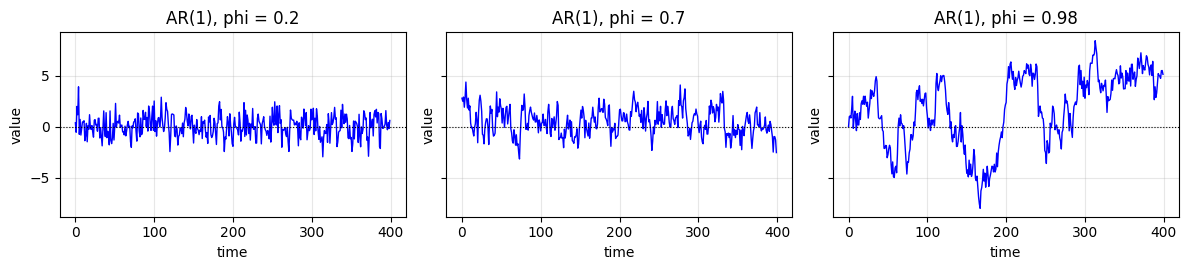

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 2.8), sharey=True)
for ax, ph in zip(axes, [0.2, 0.7, 0.98]):
    x = ArmaProcess(ar=np.r_[1, -ph], ma=np.r_[1]).generate_sample(400, distrvs=rng.standard_normal)
    run_sequence_plot(x, title=f"AR(1), phi = {ph}", ax=ax)
    ax.axhline(0, color="k", lw=.8, ls=":")
plt.tight_layout(); plt.show()

## Random walk -- the archetypal nonstationary process

$$
x_t \;=\; x_{t-1} + \varepsilon_t \;=\; x_0 + \sum_{i=1}^{t}\varepsilon_i ,
\qquad \varepsilon_i \stackrel{iid}{\sim} \mathcal{N}(0,\sigma^2).
$$

Its mean is constant, $\mathbb{E}[x_t] = x_0$, so condition 1 holds. But

$$
\mathrm{Var}(x_t) \;=\; \mathrm{Var}\Big(\sum_{i=1}^{t}\varepsilon_i\Big) \;=\; t\,\sigma^2 ,
$$

which **grows without bound** -- condition 2 fails, and the process is nonstationary. Since stationarity is
a property of the ensemble, the honest way to see this is to simulate many realizations and watch the
spread widen.

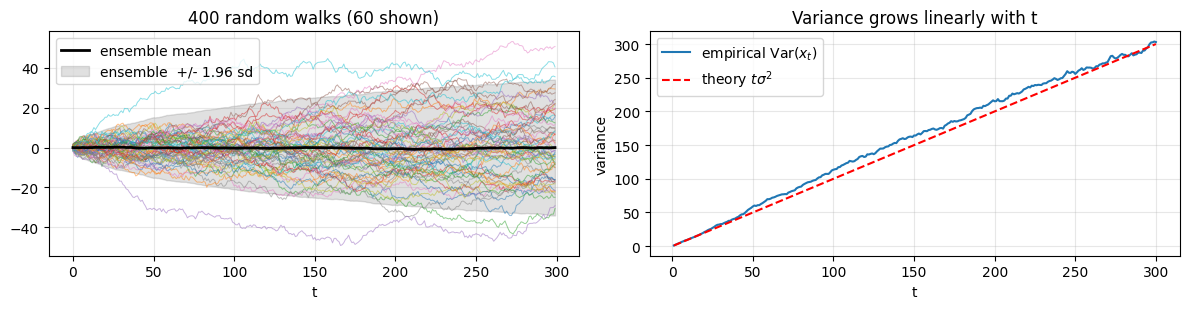

In [7]:
n_steps, n_paths, sigma = 300, 400, 1.0
steps = rng.normal(0, sigma, size=(n_paths, n_steps))
walks = np.cumsum(steps, axis=1)          # each row is one realization
t = np.arange(1, n_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))

axes[0].plot(walks[:60].T, lw=.7, alpha=.5)
axes[0].plot(walks.mean(axis=0), "k", lw=2, label="ensemble mean")
band = walks.std(axis=0)
axes[0].fill_between(np.arange(n_steps), -1.96 * band, 1.96 * band, color="k", alpha=.12,
                     label="ensemble  +/- 1.96 sd")
axes[0].set(title=f"{n_paths} random walks (60 shown)", xlabel="t"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(t, walks.var(axis=0), label="empirical Var$(x_t)$")
axes[1].plot(t, t * sigma ** 2, "r--", label=r"theory $t\sigma^2$")
axes[1].set(title="Variance grows linearly with t", xlabel="t", ylabel="variance")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

The ensemble mean stays flat at 0 while the spread widens like $\sqrt{t}$: a textbook violation of
condition 2. A random walk has a **unit root**, and its cure is one difference --
$\Delta x_t = x_t - x_{t-1} = \varepsilon_t$ is white noise. That is the whole idea behind the "I" in ARIMA.

## Trend -- nonconstant mean

$x_t = a + b t + \varepsilon_t$. Condition 1 fails: the expected value depends on $t$. 

Note that a *linear* trend can be removed either by subtracting a fitted line (**deterministic** view) or by differencing once (**stochastic** view). 

## Heteroscedasticity -- nonconstant variance

The level can be perfectly flat while the spread changes. Condition 2 fails. Very common in economic and sensor data, where the amplitude of the fluctuations scales with the level of the series.

## Seasonality and trend + seasonality

A fixed-period component makes $\mathbb{E}[x_t]$ depend on the position in the cycle, so condition 1 fails even though the series returns to the same level once per year. Most real series combine trend, seasonality and noise, which is precisely the decomposition of Chapter 2.

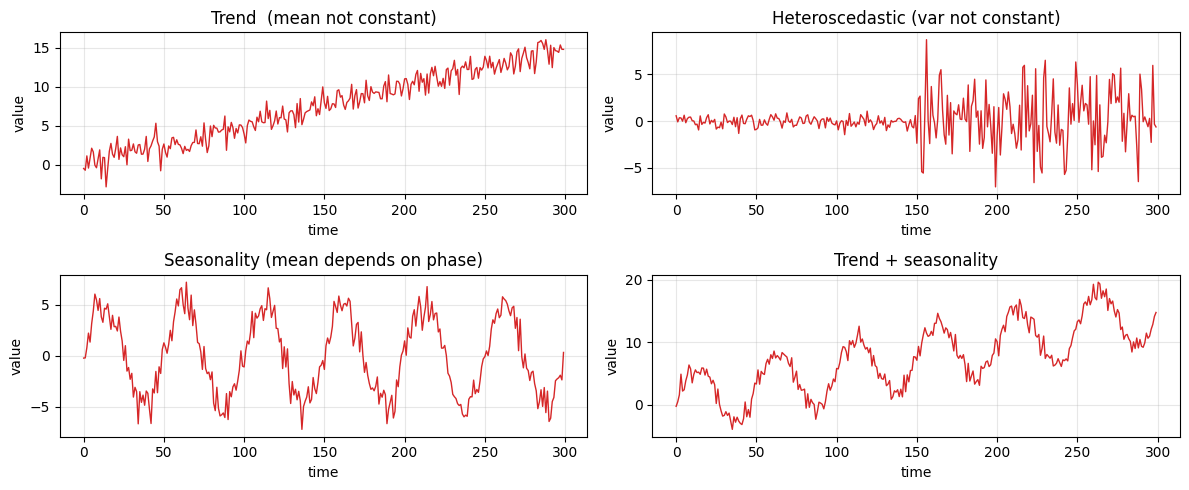

In [8]:
n = 300
t = np.arange(n)

trend_series  = 0.05 * t + rng.normal(0, 1, n)

hetero_series = np.r_[rng.normal(0, 0.5, n // 2), rng.normal(0, 3.0, n - n // 2)]

season_series = 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)

trend_season  = 0.05 * t + 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)

gallery = {
    "Trend  (mean not constant)":            trend_series,
    "Heteroscedastic (var not constant)":    hetero_series,
    "Seasonality (mean depends on phase)":   season_series,
    "Trend + seasonality":                   trend_season,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
for ax, (name, s) in zip(axes.ravel(), gallery.items()):
    run_sequence_plot(s, title=name, ax=ax, color="tab:red")
plt.tight_layout(); plt.show()

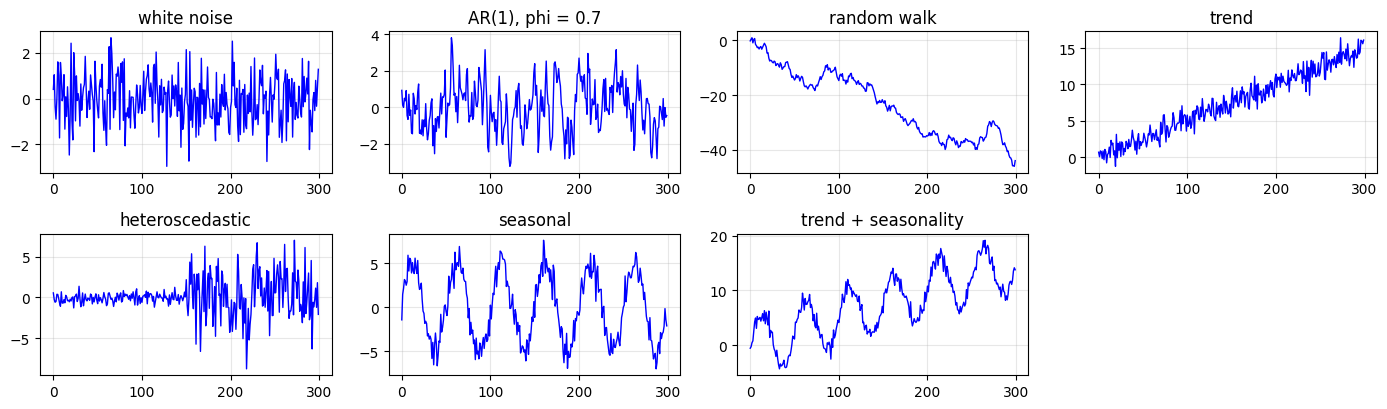

In [9]:
rng = np.random.default_rng(8999)          # reset, so this notebook is reproducible on its own

n = 300
t = np.arange(n)

white_noise   = rng.normal(0.0, 1.0, n)                                   # stationary reference
ar1           = ArmaProcess(ar=np.r_[1, -0.7], ma=np.r_[1]).generate_sample(n, distrvs=rng.standard_normal)
random_walk   = np.cumsum(rng.normal(size=n))                             # unit root
trend_series  = 0.05 * t + rng.normal(0, 1, n)                            # mean not constant
hetero_series = np.r_[rng.normal(0, 0.5, n // 2), rng.normal(0, 3.0, n - n // 2)]   # variance not constant
season_series = 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)      # fixed-period seasonality
trend_season  = 0.05 * t + 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)

chapter = {
    "white noise":         white_noise,
    "AR(1), phi = 0.7":    ar1,
    "random walk":         random_walk,
    "trend":               trend_series,
    "heteroscedastic":     hetero_series,
    "seasonal":            season_series,
    "trend + seasonality": trend_season,
}

fig, axes = plt.subplots(2, 4, figsize=(14, 4.2))
for ax, (name, s) in zip(axes.ravel(), chapter.items()):
    run_sequence_plot(s, title=name, ax=ax, xlabel="", ylabel="")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

## A periodic series that is stationary

Consider the sinusoid with a **random phase**

$$
x_t \;=\; A\sin(2\pi f t + \varphi), \qquad \varphi \sim \mathrm{Uniform}(0, 2\pi).
$$

Any single realization oscillates forever and looks obviously "seasonal". But averaged over the ensemble
(i.e. over the random phase),

$$
\mathbb{E}[x_t] \;=\; \frac{1}{2\pi}\int_0^{2\pi} A\sin(2\pi f t + \varphi)\, d\varphi \;=\; 0
\quad\text{for every } t,
$$

$$
\mathrm{Cov}(x_t, x_{t+k}) \;=\; \frac{A^2}{2}\cos(2\pi f k),
$$

which depends only on the lag $k$. All three conditions hold, so this process is **weakly stationary**.


E[x_t] at t =   0 :  7.02e-17
E[x_t] at t =   7 :  1.96e-16
E[x_t] at t = 123 :  3.71e-16


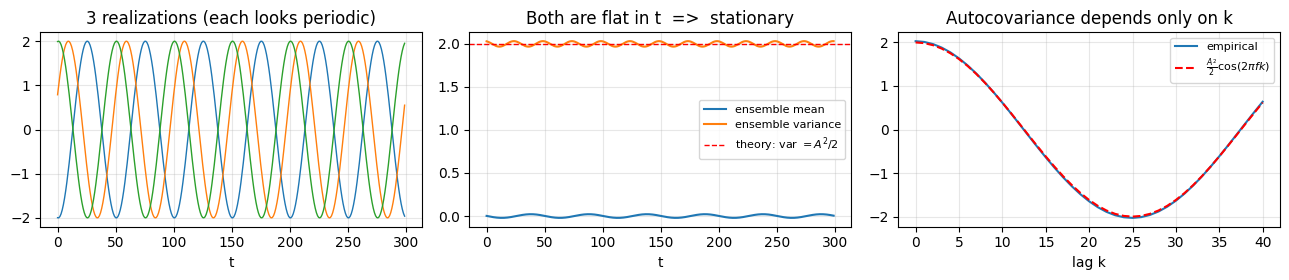

In [10]:
A, f, n = 2.0, 1 / 50, 300
t = np.arange(n)

# (a) the ensemble mean at a few fixed times, by numerical integration over the phase
for t_fixed in [0, 7, 123]:
    val, _ = quad(lambda ph: A * np.sin(2 * np.pi * f * t_fixed + ph) / (2 * np.pi), 0, 2 * np.pi)
    print(f"E[x_t] at t = {t_fixed:>3} : {val: .2e}")

# (b) Monte Carlo over 5000 realizations, each with its own random phase
phases = rng.uniform(0, 2 * np.pi, size=(5000, 1))
ensemble = A * np.sin(2 * np.pi * f * t + phases)

fig, axes = plt.subplots(1, 3, figsize=(13, 2.9))
axes[0].plot(ensemble[:3].T, lw=1)
axes[0].set(title="3 realizations (each looks periodic)", xlabel="t"); axes[0].grid(alpha=.3)

axes[1].plot(ensemble.mean(axis=0), label="ensemble mean")
axes[1].plot(ensemble.var(axis=0),  label="ensemble variance")
axes[1].axhline(A ** 2 / 2, color="r", ls="--", lw=1, label=r"theory: var $= A^2/2$")
axes[1].set(title="Both are flat in t  =>  stationary", xlabel="t"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

emp_cov = np.array([(ensemble[:, 0] * ensemble[:, k]).mean() for k in range(41)])
axes[2].plot(emp_cov, label="empirical")
axes[2].plot(A ** 2 / 2 * np.cos(2 * np.pi * f * np.arange(41)), "r--", label=r"$\frac{A^2}{2}\cos(2\pi f k)$")
axes[2].set(title="Autocovariance depends only on k", xlabel="lag k"); axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**The lesson.** Stationarity is defined over the ensemble; a single realization can be misleading in both directions. 
In applied work we only ever have one realization, so we combine plots, summary statistics and formal tests, and we stay aware that each of them can be fooled.

**Summary of the gallery**

| Process | Mean | Variance | $\gamma(k)$ depends only on $k$ | Stationary? |
|---|---|---|---|---|
| White noise | constant | constant | yes ($\gamma(k)=0$, $k\neq0$) | **yes** |
| AR(1), $\lvert\phi\rvert<1$ | constant | constant | yes | **yes** |
| Random-phase sinusoid | constant (0) | constant ($A^2/2$) | yes | **yes** |
| Random walk | constant | $t\sigma^2$, grows | no | no |
| Random walk with drift | grows | grows | no | no |
| Trend | grows | constant | no | no |
| Heteroscedastic | constant | changes | no | no |
| Seasonal | depends on phase | constant | no | no |
| Trend + seasonality | changes | often changes | no | no |

# Summary

1. **Weak stationarity** = constant mean, constant finite variance, and an autocovariance
   $\gamma(k)=\mathrm{Cov}(x_t,x_{t+k})$ that depends only on the lag $k$. Unqualified, "stationary" means
   this. Strict stationarity constrains the whole joint distribution and is not something we can check.
2. It is a property of the **process**, not of your sample. We judge it from a single realization, so every
   diagnostic is evidence rather than proof -- as the random-phase sinusoid showed, one realization can look
   convincingly periodic while the process is perfectly stationary.
3. Stationarity is what makes a single set of estimated parameters meaningful, and it is the assumption
   underneath the entire ARMA family.
4. Learn the gallery. **Stationary**: white noise, AR(1) with $\lvert\phi\rvert<1$, random-phase sinusoid.
   **Nonstationary**: random walk (variance grows as $t\sigma^2$), trend, heteroscedasticity, seasonality,
   and the usual real-world combination of all of them.
5. Stationary does **not** mean independent: an AR(1) is correlated across time and stationary at once.
   And oscillating does not mean nonstationary -- a *fixed-period* seasonal pattern breaks stationarity, a
   cycle of variable period and phase need not.

**Next**: Detecting stationarity, where we turn these definitions into diagnostics (chunk and rolling statistics, ADF, KPSS) and into the transformations that make a nonstationary series usable.